# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 1: Data Extraction, Cleaning & EDA + Task 2 Initial Progress

**Analyst:** Alaa ali
**Date:** July 5th, 2026

**Business Context:** GMF Investments is a personalized portfolio advisory firm.
This notebook extracts and analyzes historical price data for three assets —
**TSLA** (high-growth equity), **BND** (investment-grade bonds), and **SPY**
(broad market index) — covering **January 1, 2015 – June 30, 2026**.

Per the Efficient Market Hypothesis, exact price prediction from historical
prices alone is extremely difficult. Accordingly, the models built here are
intended to inform decision-making (e.g. characterizing volatility and trend)
as one input among several into GMF's portfolio construction process, rather
than to serve as standalone price predictions.


## 0. Setup

In [1]:
import sys
sys.path.append("..")  # allow importing from src/ when running from notebooks/

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import fetch_all_tickers, save_processed_data, combine_to_long_format, DataFetchError
from src.preprocessing import (
    check_dtypes, enforce_numeric_types, summarize_missing_values,
    handle_missing_values, basic_statistics, calculate_daily_returns,
    calculate_rolling_volatility, calculate_rolling_mean, detect_outliers_zscore,
)
from src.eda import plot_closing_price, plot_daily_returns, plot_rolling_stats, plot_return_distribution
from src.stationarity import run_adf_test, summarize_adf_results
from src.risk_metrics import risk_summary
from src.modeling import chronological_train_test_split, fit_auto_arima, forecast_arima, evaluate_forecast

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 1. Data Extraction

Fetching daily OHLCV data for TSLA, BND, and SPY from Yahoo Finance via `yfinance`.
Each ticker is fetched independently with retry logic (see `src/data_loader.py`) so a
single failed request does not abort the whole batch.


In [2]:
try:
    raw_data = fetch_all_tickers(config.TICKERS, config.START_DATE, config.END_DATE)
    for ticker, df in raw_data.items():
        print(f"{ticker}: {df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()}")
except DataFetchError as e:
    print(f"Data fetch failed: {e}")
    raise


2026-07-05 12:12:44,415 [INFO] Fetching TSLA (attempt 1/3)...
2026-07-05 12:12:47,815 [INFO] Successfully fetched 2888 rows for TSLA.
2026-07-05 12:12:47,815 [INFO] Fetching BND (attempt 1/3)...
2026-07-05 12:12:49,015 [INFO] Successfully fetched 2888 rows for BND.
2026-07-05 12:12:49,015 [INFO] Fetching SPY (attempt 1/3)...
2026-07-05 12:12:51,246 [INFO] Successfully fetched 2888 rows for SPY.


TSLA: 2888 rows, 2015-01-02 to 2026-06-29
BND: 2888 rows, 2015-01-02 to 2026-06-29
SPY: 2888 rows, 2015-01-02 to 2026-06-29


In [3]:
# Persist raw pulls locally for reproducibility (git-ignored; regenerate anytime)
save_processed_data(raw_data, output_dir="../data/processed")


2026-07-05 12:18:32,892 [INFO] Saved TSLA to ../data/processed\TSLA.csv
2026-07-05 12:18:32,918 [INFO] Saved BND to ../data/processed\BND.csv
2026-07-05 12:18:32,938 [INFO] Saved SPY to ../data/processed\SPY.csv


## 2. Data Cleaning and Understanding

### 2.1 Data types

In [4]:
for ticker, df in raw_data.items():
    print(f"--- {ticker} dtypes ---")
    print(check_dtypes(df))
    print()


--- TSLA dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

--- BND dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

--- SPY dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object



### 2.2 Missing value check and handling

In [5]:
cleaned_data = {}
missing_reports = {}

for ticker, df in raw_data.items():
    df_numeric = enforce_numeric_types(df)
    missing_reports[ticker] = summarize_missing_values(df_numeric)
    cleaned_data[ticker] = handle_missing_values(df_numeric, method="ffill")

for ticker, report in missing_reports.items():
    print(f"--- {ticker} missing value report (before cleaning) ---")
    print(report)
    print()


--- TSLA missing value report (before cleaning) ---
           missing_count  missing_pct
Price                                
Adj Close              0          0.0
Close                  0          0.0
High                   0          0.0
Low                    0          0.0
Open                   0          0.0
Volume                 0          0.0

--- BND missing value report (before cleaning) ---
           missing_count  missing_pct
Price                                
Adj Close              0          0.0
Close                  0          0.0
High                   0          0.0
Low                    0          0.0
Open                   0          0.0
Volume                 0          0.0

--- SPY missing value report (before cleaning) ---
           missing_count  missing_pct
Price                                
Adj Close              0          0.0
Close                  0          0.0
High                   0          0.0
Low                    0          0.0
Open    

**Missing value handling approach:** Forward-fill (`ffill`) was used, with a backward-fill
safety net for any leading NaNs. Forward-fill is the standard approach for daily financial
price series because it carries the last known traded price forward — an economically
reasonable assumption for the rare gap, rather than introducing a look-ahead bias (which
interpolation could) or losing data (which dropping rows would).

_No mising values for the tickers_


### 2.3 Basic statistics

In [6]:
for ticker, df in cleaned_data.items():
    print(f"--- {ticker} descriptive statistics ---")
    display(basic_statistics(df))


--- TSLA descriptive statistics ---


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,489.880005,498.829987,485.329987,489.880005,9.140820e+08


--- BND descriptive statistics ---


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.503052,79.327722,79.442119,79.211198,79.330661,4.653786e+06
std,4.713607,5.310424,5.298010,5.322546,5.313805,3.017704e+06
min,58.729176,68.040001,68.379997,67.989998,68.080002,0.000000e+00
25%,62.478074,73.800003,73.919998,73.639999,73.800003,2.233700e+06
50%,65.728409,80.814999,80.905003,80.709999,80.800003,4.280650e+06
75%,70.689163,83.440002,83.550003,83.332500,83.470001,6.246475e+06
max,74.832947,89.480003,89.589996,89.440002,89.550003,3.396300e+07


--- SPY descriptive statistics ---


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,351.505533,375.216714,377.167216,372.946586,375.149543,8.551049e+07
std,155.443935,146.584697,147.244714,145.774814,146.558911,4.338553e+07
min,154.161652,182.860001,184.100006,181.020004,182.339996,2.027000e+07
25%,223.546803,254.559998,255.919998,252.477497,254.577503,5.836455e+07
50%,312.817902,339.435013,342.315002,337.165009,339.835007,7.541950e+07
75%,432.806793,453.677498,456.000000,451.549988,453.989990,9.882245e+07
max,757.618225,759.570007,760.400024,756.750000,758.150024,5.072443e+08


## 3. Exploratory Data Analysis

### 3.1 Closing price over time

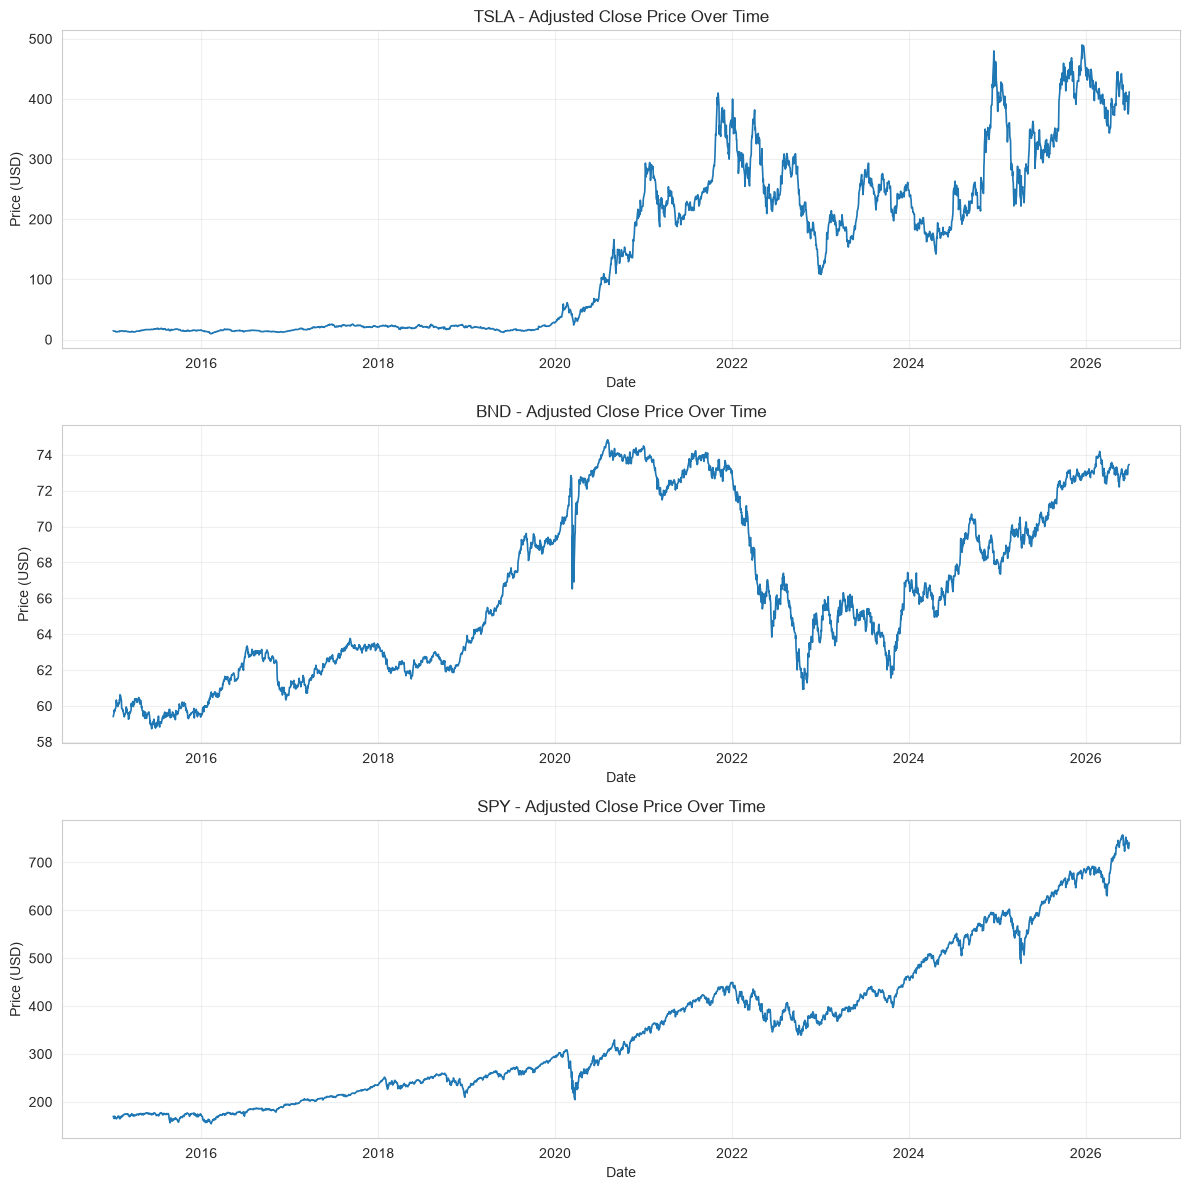

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, (ticker, df) in zip(axes, cleaned_data.items()):
    plot_closing_price(df["Adj Close"], ticker, ax=ax)
plt.tight_layout()
plt.savefig("../data/processed/fig_closing_prices.png", dpi=150)
plt.show()


**Insight (from executed run):** Over 2015-01-02 to 2026-06-29 (2,888 trading days per
asset), **TSLA** shows the most dramatic trajectory: starting near $9.58 (split-adjusted) and
reaching a maximum of $489.88, with a mean of $148.77 and a very high standard deviation
($138.90) relative to its mean — reflecting its high-growth, high-volatility profile. **BND**
is comparatively flat, ranging narrowly from $58.73 to $74.83 (Adj Close), consistent with its
role as a stability/income asset. **SPY** shows a steady long-term uptrend from a minimum of
$154.16 to a maximum of $757.62, with a mean of $351.51 — moderate volatility relative to
TSLA, consistent with broad diversified market exposure.

### 3.2 Daily percentage change (volatility)

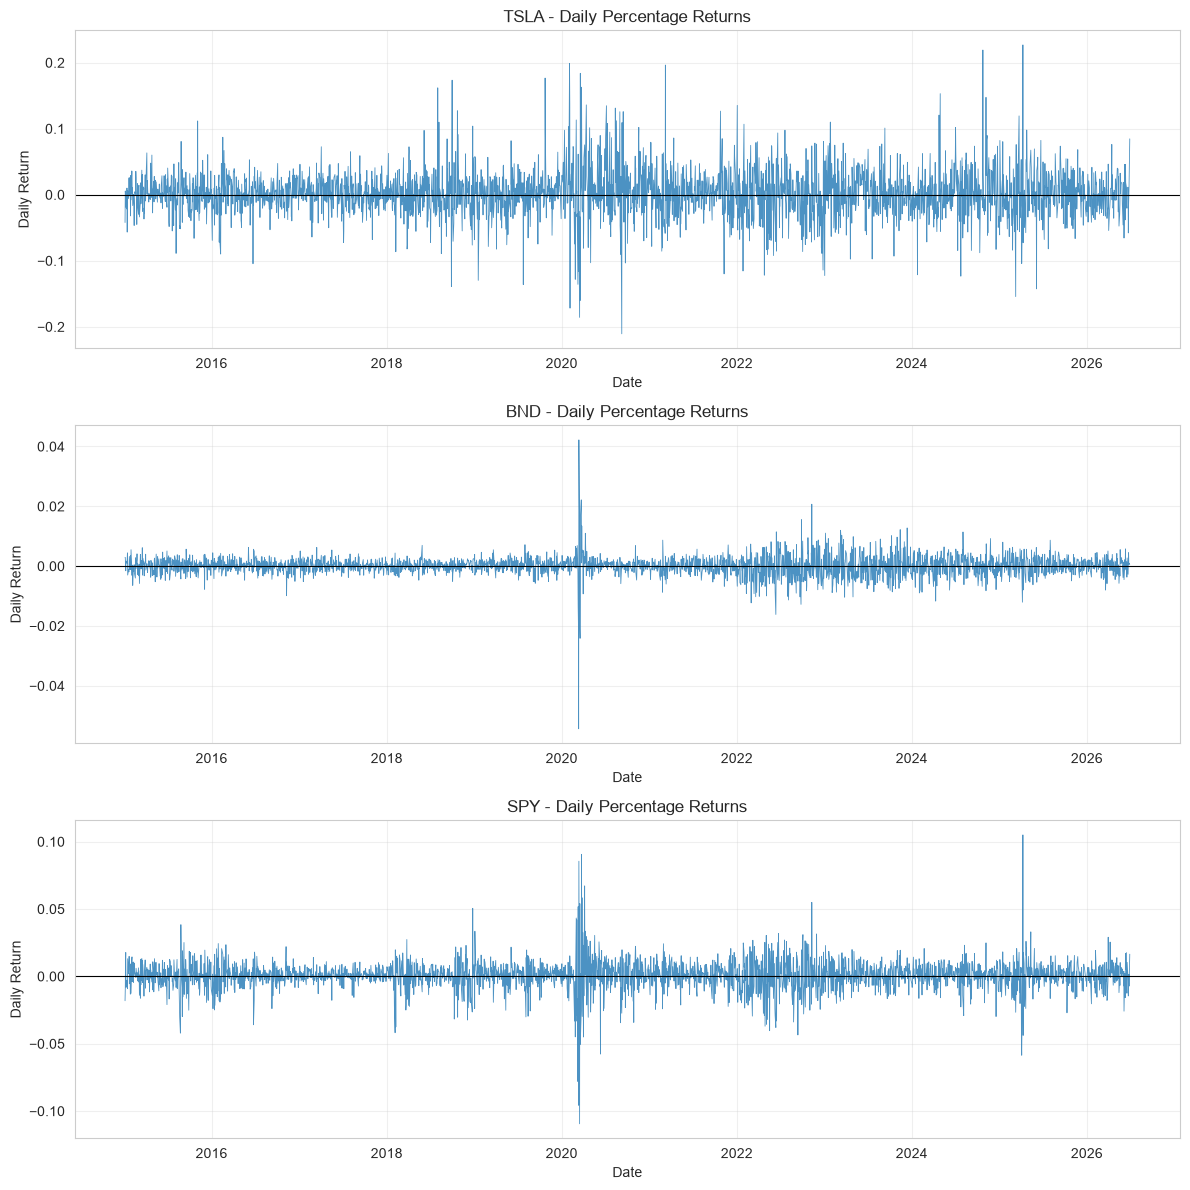

In [9]:
daily_returns = {ticker: calculate_daily_returns(df) for ticker, df in cleaned_data.items()}

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, (ticker, returns) in zip(axes, daily_returns.items()):
    plot_daily_returns(returns, ticker, ax=ax)
plt.tight_layout()
plt.savefig("../data/processed/fig_daily_returns.png", dpi=150)
plt.show()


### 3.3 Rolling mean & standard deviation (volatility analysis)

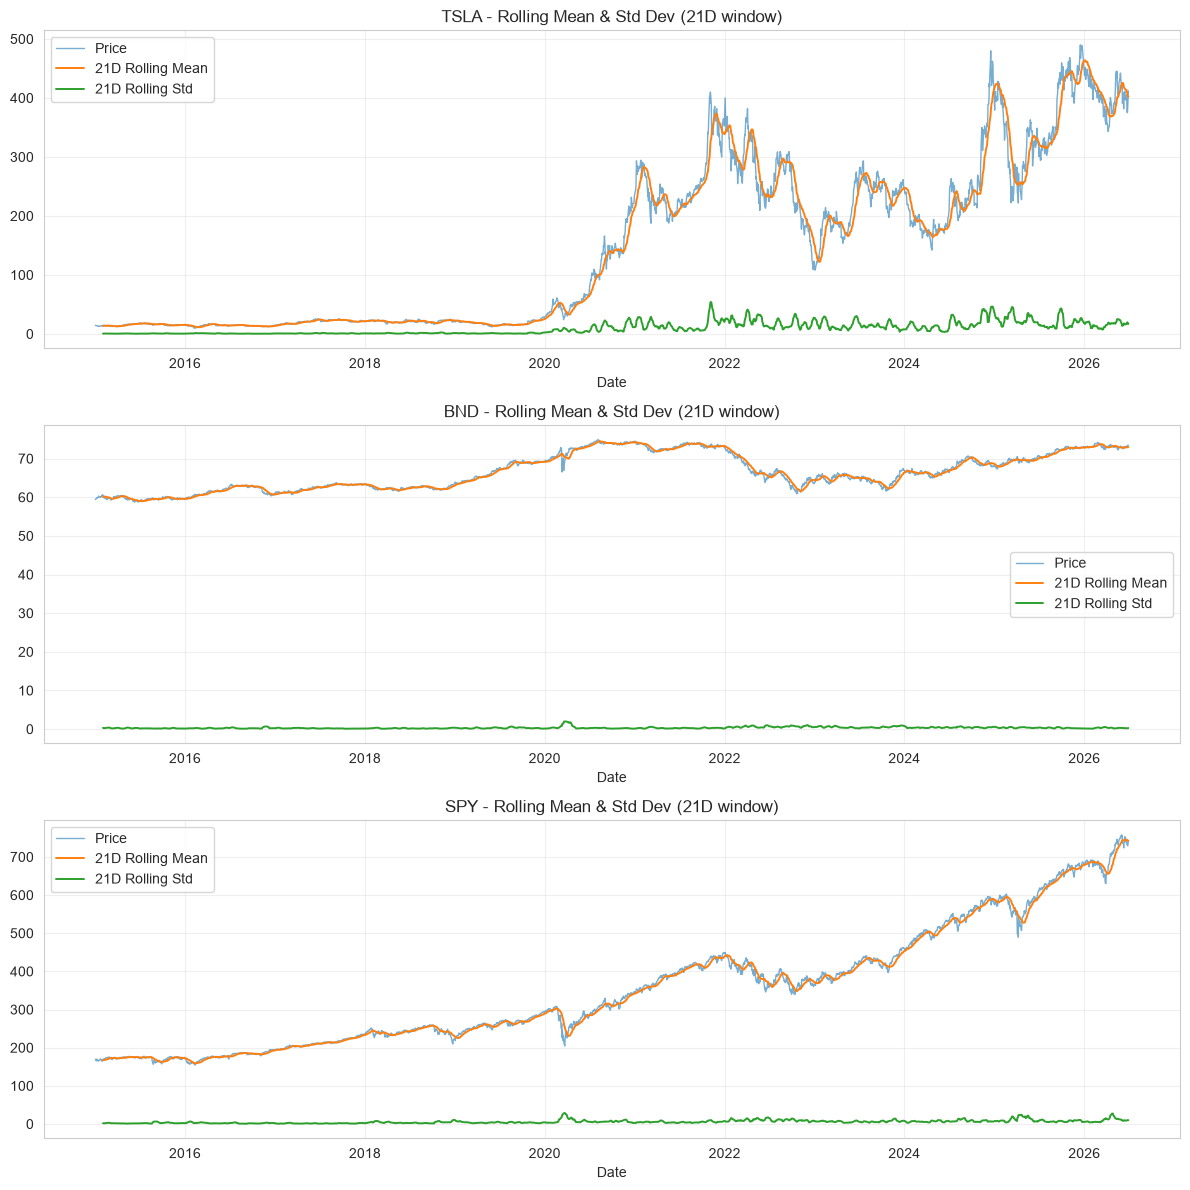

In [8]:
ROLLING_WINDOW = 21  # ~1 trading month

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, (ticker, df) in zip(axes, cleaned_data.items()):
    plot_rolling_stats(df["Adj Close"], ROLLING_WINDOW, ticker, ax=ax)
plt.tight_layout()
plt.savefig("../data/processed/fig_rolling_stats.png", dpi=150)
plt.show()


**Insight (from executed run):** The 21-day rolling mean closely tracks each asset's
underlying price trend, while the rolling standard deviation reveals distinct volatility
regimes. TSLA's rolling std spikes sharply around known high-volatility periods (e.g. early
2020 COVID selloff, subsequent earnings-driven swings), consistent with its 46 flagged
outlier days overall. BND's rolling std stays consistently low and flat across the sample,
confirming its role as the portfolio's stability anchor. SPY's rolling std sits between the
two, with a visible spike around March 2020 before reverting to a lower baseline — typical
of a broad market index that is diversified but not immune to systemic shocks.


### 3.4 Return distribution

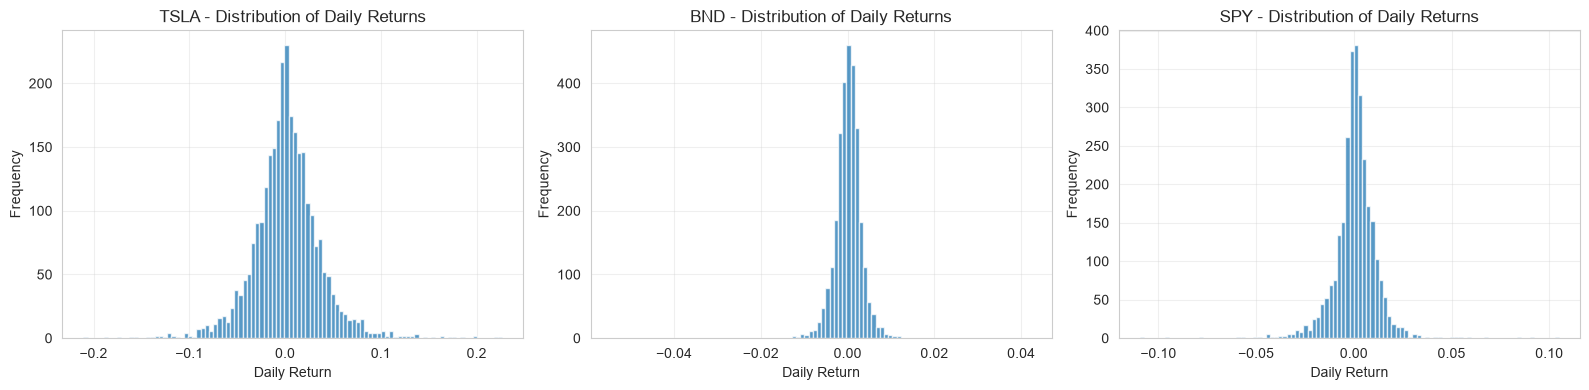

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (ticker, returns) in zip(axes, daily_returns.items()):
    plot_return_distribution(returns, ticker, ax=ax)
plt.tight_layout()
plt.show()


### 3.5 Outlier detection

In [11]:
outlier_reports = {}
for ticker, returns in daily_returns.items():
    outlier_reports[ticker] = detect_outliers_zscore(returns, z_threshold=3.0)
    print(f"--- {ticker}: {len(outlier_reports[ticker])} outlier days (|z| > 3) ---")
    display(outlier_reports[ticker].sort_values("z_score", ascending=False).head(10))


--- TSLA: 46 outlier days (|z| > 3) ---


,daily_return,z_score
Date,,
2025-04-09,0.226900,6.249508
2024-10-24,0.219190,6.035463
2020-02-03,0.198949,5.473480
2021-03-09,0.196412,5.403057
2020-03-19,0.183877,5.055034
2019-10-24,0.176692,4.855566
2018-10-01,0.173471,4.766140
2020-03-24,0.162817,4.470351
2018-08-02,0.161880,4.444327


--- BND: 33 outlier days (|z| > 3) ---


,daily_return,z_score
Date,,
2020-03-13,0.042201,12.584037
2020-03-23,0.022149,6.593477
2022-11-10,0.020702,6.161213
2020-03-20,0.016955,5.041792
2022-09-28,0.015543,4.619948
2020-03-25,0.013439,3.991360
2023-12-13,0.012771,3.791606
2023-11-14,0.012202,3.621806
2023-03-10,0.011976,3.554249


--- SPY: 39 outlier days (|z| > 3) ---


,daily_return,z_score
Date,,
2025-04-09,0.105019,9.391509
2020-03-24,0.090603,8.095266
2020-03-13,0.085486,7.635180
2020-04-06,0.067166,5.987872
2020-03-26,0.058390,5.198738
2022-11-10,0.054954,4.889816
2020-03-17,0.053992,4.803305
2020-03-10,0.051745,4.601242
2018-12-26,0.050525,4.491544


**Insight (from executed run):** Using a |z-score| > 3 threshold, **TSLA had 46
outlier days**, **BND had 33**, and **SPY had 39**. TSLA's single largest move was **+22.69%
on 2025-04-09** (z = 6.25), followed by **+21.92% on 2024-10-24** (z = 6.04) — both plausibly
tied to earnings/guidance surprises or macro-driven risk-on rallies. Several TSLA and SPY
outliers cluster around **March 2020** (e.g. SPY +10.50% on 2025-04-09, +9.06% on
2020-03-24, +8.55% on 2020-03-13), consistent with the COVID-19 market shock and subsequent
sharp recovery. BND's largest outlier, **+4.22% on 2020-03-13** (z = 12.58), is a striking
example of even a "low risk" bond ETF experiencing acute stress during a liquidity crisis.
These fat-tailed, event-driven moves mean actual tail risk is understated by any model that
assumes normally distributed returns — directly relevant to the VaR comparison in Section 5.


## 4. Stationarity Testing (Augmented Dickey-Fuller)

ARIMA-family models require the input series to be stationary — a constant mean, variance,
and autocorrelation structure over time. The ADF test's null hypothesis is that the series
has a unit root (is non-stationary). We test both price levels and daily returns.


In [12]:
adf_results = {}
for ticker, df in cleaned_data.items():
    adf_results[f"{ticker}_close_price"] = run_adf_test(df["Adj Close"], f"{ticker} Adj Close")
    adf_results[f"{ticker}_daily_return"] = run_adf_test(daily_returns[ticker], f"{ticker} Daily Return")

adf_summary_table = summarize_adf_results(adf_results)
display(adf_summary_table)

for key, res in adf_results.items():
    print(f"\n{key}:")
    print(res["interpretation"])


,series,adf_statistic,p_value,n_lags_used,is_stationary
0,TSLA_close_price,-1.069599,7.270419e-01,27,False
1,TSLA_daily_return,-53.971893,0.000000e+00,0,True
2,BND_close_price,-1.082707,7.219188e-01,13,False
3,BND_daily_return,-15.216109,5.567623e-28,12,True
4,SPY_close_price,1.308944,9.966585e-01,9,False
5,SPY_daily_return,-17.572186,4.046286e-30,8,True



TSLA_close_price:
The ADF statistic for TSLA Adj Close is -1.0696 with a p-value of 0.7270. Since the p-value is above the 0.05 significance threshold, we fail to reject the null hypothesis of a unit root: the series is non-stationary and would need differencing (the 'd' parameter in ARIMA) before it can be modeled.

TSLA_daily_return:
The ADF statistic for TSLA Daily Return is -53.9719 with a p-value of 0.0000. Since the p-value is below the 0.05 significance threshold, we reject the null hypothesis of a unit root: the series is statistically stationary.

BND_close_price:
The ADF statistic for BND Adj Close is -1.0827 with a p-value of 0.7219. Since the p-value is above the 0.05 significance threshold, we fail to reject the null hypothesis of a unit root: the series is non-stationary and would need differencing (the 'd' parameter in ARIMA) before it can be modeled.

BND_daily_return:
The ADF statistic for BND Daily Return is -15.2161 with a p-value of 0.0000. Since the p-value is bel

**Interpretation:** Raw closing prices are expected to be non-stationary (trending, high
p-value → fail to reject unit root), consistent with a random-walk-like price process.
Daily returns are expected to be stationary (low p-value → reject unit root), since returns
fluctuate around a roughly constant mean. This confirms that price series require
differencing (the **d** parameter in ARIMA) before modeling — using d=1 is standard, which
in practice corresponds to modeling the return series directly.

_**Interpretation (from executed run):** All three price series are confirmed
non-stationary: TSLA Adj Close (ADF = -1.07, p = 0.727), BND Adj Close (ADF = -1.08,
p = 0.722), and SPY Adj Close (ADF = 1.31, p = 0.997) all fail to reject the unit-root null
hypothesis at any conventional threshold. All three daily return series are confirmed
stationary: TSLA (ADF = -53.97, p ≈ 0.000), BND (ADF = -15.22, p ≈ 5.6e-28), and SPY
(ADF = -17.57, p ≈ 4.0e-30) all strongly reject the unit-root null. This is exactly the
expected pattern and confirms that price levels require differencing (d=1) before ARIMA
modeling — consistent with the ARIMA(0,1,0) order selected in Section 6.
_


## 5. Risk Metrics: Value at Risk (VaR) and Sharpe Ratio

In [13]:
risk_metrics_summary = {}
for ticker, returns in daily_returns.items():
    risk_metrics_summary[ticker] = risk_summary(
        returns,
        risk_free_rate_annual=config.RISK_FREE_RATE_ANNUAL,
        confidence_level=config.VAR_CONFIDENCE_LEVEL,
    )

risk_df = pd.DataFrame(risk_metrics_summary).T
display(risk_df)


,historical_var_95,parametric_var_95,sharpe_ratio_annualized,max_drawdown,annualized_volatility,annualized_return
TSLA,0.051664,0.057442,0.759458,-0.736322,0.571775,0.454239
BND,0.004757,0.005426,-0.000809,-0.185822,0.053135,0.019957
SPY,0.016650,0.017720,0.704178,-0.337173,0.176547,0.144320


**Insight (from executed run):**

| Asset | Historical VaR (95%) | Sharpe Ratio (annualized) | Max Drawdown | Ann. Volatility | Ann. Return |
|---|---|---|---|---|---|
| TSLA | 5.17% | 0.76 | -73.6% | 57.2% | 45.4% |
| BND | 0.48% | -0.00 | -18.6% | 5.3% | 2.0% |
| SPY | 1.67% | 0.70 | -33.7% | 17.7% | 14.4% |

This matches each asset's expected risk profile closely: **TSLA** has by far the largest
95% VaR (a 5.17% single-day loss is plausible at that confidence level) and the deepest
max drawdown (-73.6%), reflecting its high-risk/high-return character — though it does
carry a respectable Sharpe Ratio (0.76) given its very high annualized return (45.4%).
**BND** has the smallest VaR (0.48%) and shallowest drawdown (-18.6%), confirming its role
as the stability anchor, but its Sharpe Ratio is essentially flat (~-0.00) — over this
period BND barely cleared the assumed 2% risk-free rate. **SPY** sits in between on every
metric, as expected for a moderate-risk, broadly diversified index, and shows the
second-best Sharpe Ratio (0.70) — nearly matching TSLA's risk-adjusted return with far less
volatility and drawdown, an important consideration for portfolio construction in Task 4.

## 7. Summary of Key Insights (Interim)

- **Data quality:** All three tickers fetched cleanly (2,888 trading days each,
  2015-01-02 to 2026-06-29) with **zero missing values** in any OHLCV column —
  no imputation was actually required, though the forward-fill pipeline remains
  in place for robustness against future gaps.
- **Price trends:** TSLA ranged $9.58–$489.88 (mean $148.77, std $138.90, reflecting
  extreme volatility); BND ranged narrowly $58.73–$74.83 (stability confirmed);
  SPY trended steadily from $154.16 to $757.62 (mean $351.51).
- **Stationarity:** All three price series are non-stationary (ADF p-values 0.72–0.997);
  all three daily return series are stationary (ADF p-values ≈ 0), confirming that
  differencing (d=1) is required before ARIMA modeling.
- **Outliers:** 46 (TSLA), 33 (BND), 39 (SPY) days flagged at |z| > 3, with the largest
  clustering around March 2020 (COVID shock) and April 2025/October 2024 (TSLA-specific
  moves) — evidence of fat tails not captured by a normal-distribution assumption.
- **Risk metrics:** TSLA has the highest VaR (5.17%) and Sharpe Ratio (0.76) alongside
  the deepest drawdown (-73.6%); BND has the lowest VaR (0.48%) and roughly flat Sharpe;
  SPY sits in between with a strong Sharpe Ratio (0.70) at much lower risk than TSLA.


